In [19]:
import streamlit as st
from streamlit_jupyter import StreamlitPatcher, tqdm
StreamlitPatcher().jupyter()  # register streamlit with jupyter-compatible wrappers
import sys; sys.path.append('..')
from osp import *
pd.options.display.max_colwidth = 200
pd.options.display.max_rows = 20
groups_train = COMPARISONS[0]

In [20]:
def get_random_doc():
    ids = get_parsed_slice_ids()
    id = random.choice(ids)
    docstr = STASH_SLICES_NLP[id]
    doc = stanza.Document.from_serialized(docstr)
    return doc

def get_random_sent():
    doc = get_random_doc()
    sent = random.choice(doc.sentences)
    return sent

In [21]:
sent = get_random_sent()
sent.text

'This distinction does not seem to involve a real difficulty.'

In [49]:
def get_phrase_counts_tree(tree):
    counter = Counter()
    for node in tree.subtrees():
        if is_preterminal(node): continue
        children_labels = [child.label() for child in node if child.label()[0].isalpha()]
        if len(children_labels) > 1:
            label = f'{node.label()}({",".join(children_labels)})'
            counter[label] += 1
    return counter
        
def get_phrase_counts_sent(sent):
    tree = get_sent_tree(sent)
    return get_phrase_counts_tree(tree)

def get_phrase_counts_doc(doc):
    phrase_counts = Counter()
    for sent in doc.sentences:
        phrase_counts.update(get_phrase_counts_sent(sent))
    return phrase_counts

In [50]:
sent = get_random_sent()
sent.text

'I argued that to desire something is to have a perspective from which it appears to be good (even if we reject this perspective upon reflection).'

In [51]:
get_phrase_counts_sent(sent)

Counter({'S(NP,VP)': 3,
         'VP(TO,VP)': 3,
         'VP(VBZ,S)': 2,
         'NP(DT,NN)': 2,
         'VP(VBD,SBAR)': 1,
         'SBAR(IN,S)': 1,
         'S(S,NP,VP)': 1,
         'VP(VB,NP,SBAR)': 1,
         'NP(NP,SBAR)': 1,
         'SBAR(WHPP,S)': 1,
         'WHPP(IN,WHNP)': 1,
         'VP(VB,ADJP)': 1,
         'SBAR(ADVP,IN,S)': 1,
         'VP(VBP,NP,PP)': 1,
         'PP(IN,NP)': 1})

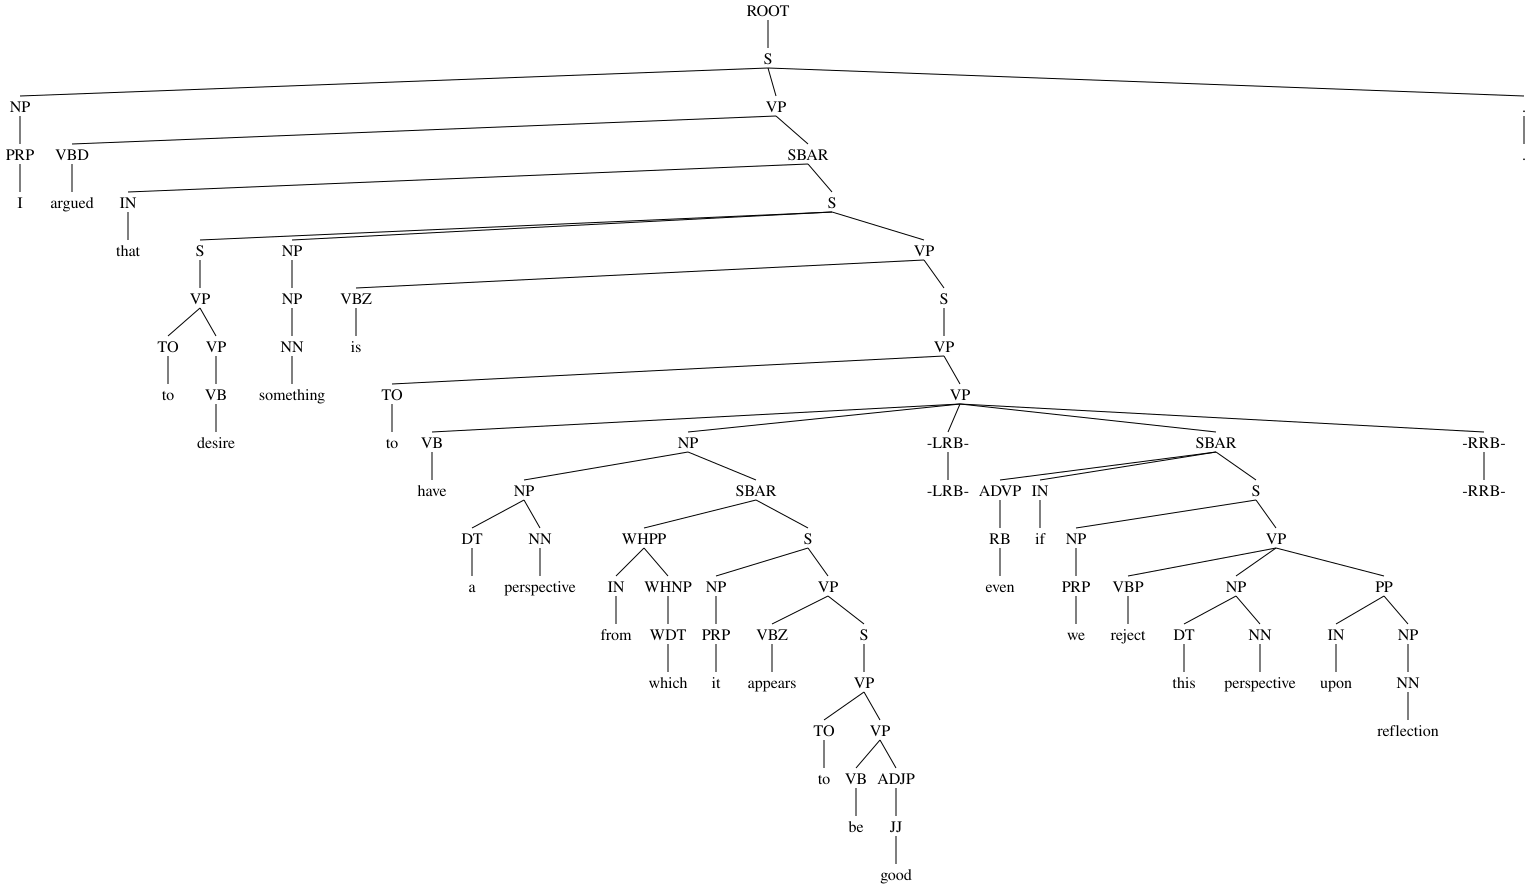

In [52]:
get_sent_tree(sent)

In [11]:
df_smpl_feats = get_balanced_slice_sample_feats(groups_train, with_diff_rows=True).reset_index()

Loading features for 2134 slices...
Filtering valid slices...
Aggregating feature statistics...
Computing difference rows...
diff_rows 1900-1925 Philosophy 1900-1925 Literature


In [17]:
df_smpl_feats

,feat,target,z,raw,z_abs,z_diff,z_diff_abs,raw_diff,raw_diff_abs,feat_rank,feat_rank1,feat_rank2
0,pos_NNP,1900-1925 Literature,1.141156,64.052067,1.141156,-1.662595,1.662595,-47.384923,47.384923,1,95,1
1,pos_NNP,1900-1925 Philosophy,-0.521439,16.667145,0.521439,-1.662595,1.662595,-47.384923,47.384923,1,95,1
2,pos_NNP,1900-1925 Philosophy - 1900-1925 Literature,-1.662595,-47.384923,1.662595,-1.662595,1.662595,-47.384923,47.384923,1,95,1
3,pos_VBD,1900-1925 Literature,0.947833,18.845975,0.947833,-1.069285,1.069285,-11.194595,11.194595,2,94,2
4,pos_VBD,1900-1925 Philosophy,-0.121452,7.651380,0.121452,-1.069285,1.069285,-11.194595,11.194595,2,94,2
...,...,...,...,...,...,...,...,...,...,...,...,...
280,pos_RBS,1900-1925 Literature,0.165001,0.780215,0.165001,0.010518,0.010518,0.009321,0.009321,94,59,37
281,pos_RBS,1900-1925 Philosophy - 1900-1925 Literature,0.010518,0.009321,0.010518,0.010518,0.010518,0.009321,0.009321,94,59,37
282,deprel_dislocated,1900-1925 Literature,0.100792,0.059614,0.100792,-0.001053,0.001053,-0.000197,0.000197,95,60,36
283,deprel_dislocated,1900-1925 Philosophy,0.099740,0.059417,0.099740,-0.001053,0.001053,-0.000197,0.000197,95,60,36


In [2]:
doc = get_nlp_doc(newtxt)
sent = doc.sentences[2]

In [3]:
clause_df = get_syntax_df(sent)

In [4]:
clause_df.head()

,clause_i,clause_id,clause_type,clause_deprel,word_i,word,word_pos,word_deprel,word_head,word_depth,clause_depth,clause_head,word_head_dist
0,0,1,main,root,0,We,PRP,nsubj,3,1,0,2,3
1,0,1,main,root,1,may,MD,aux,3,1,0,2,2
2,0,1,main,root,2,distinguish,VB,root,0,0,0,2,2
3,0,1,main,root,3,three,CD,nummod,5,2,0,2,2
4,0,1,main,root,4,cases,NNS,obj,3,1,0,2,1


In [8]:
get_slice_feat_egs()

,feature,word,count,perc,eg_text,eg_html,sent_id,word_id,slice_id
0,pos_CC,yet,1,3.7,*YET* the most typical contexts in which counterfactuals app,,18,1,phil/10.2307/20118496__02
1,pos_CC,or,5,18.5,"where laws of physics are different, or *OR* least not universally valid.\n","<span data-word-id=""10"" data-word-pos=""IN"" data-word-deprel=""case"" data-word-color-by=""weight_z"" data-word-color-val=""-1.052"" style=""background-color: #e17860; color: black; font-size: 1.2em; font...",19,15,phil/10.2307/20118496__02
2,pos_CC,and,14,51.9,of doing away with the first assumption *AND* therefore admitting some version of indeterminism (whi,"<span data-word-id=""9"" data-word-pos=""RB"" data-word-deprel=""advmod"" data-word-color-by=""weight_z"" data-word-color-val=""1.951"" style=""background-color: #08366a; color: white; font-size: 1.2em; font...",17,14,phil/10.2307/20118496__02
3,pos_CC,or,7,14.9,"and remunerative job in the industries, *OR* shops, or farms, or mines of the Nation.\n","<span data-word-id=""12"" data-word-pos=""NN"" data-word-deprel=""nmod"" data-word-color-by=""weight_z"" data-word-color-val=""1.446"" style=""background-color: #2e77b5; color: white; font-size: 1.2em; font-...",38,17,phil/10.2307/4545337__07
4,pos_CC,and,30,63.8,"*AND* there are doubts, not always groundless, about how fir",,5,1,phil/10.2307/4545337__07
...,...,...,...,...,...,...,...,...,...
873,deprel_obl:unmarked,itself,1,100.0,a certain degree of impatience which is *ITSELF* strictly determinate.\n,"<span data-word-id=""16"" data-word-pos=""NN"" data-word-deprel=""obl"" data-word-color-by=""weight_z"" data-word-color-val=""0.016"" style=""background-color: #f5f6f7; color: black; font-size: 1.2em; font-w...",19,21,phil/10.2307/2177714__05
874,deprel_obl:unmarked,way,1,50.0,erson has used the word acceptably-some *WAY* other than merely seeing if the person felt like using,"<span data-word-id=""13"" data-word-pos=""DT"" data-word-deprel=""det"" data-word-color-by=""weight_z"" data-word-color-val=""-3.609"" style=""background-color: #67001f; color: white; font-size: 1.2em; font-...",23,18,phil/10.2307/3071041__03
875,deprel_obl:unmarked,pp.,1,50.0,"SN, *PP.*\nSecond, reasons might be made agent-neutral by some de",,0,3,phil/10.2307/3071041__03
876,deprel_obl:unmarked,years,2,100.0,"Two *YEARS* after the revival, David Erskine Baker in his Biogra",,10,2,lit/459613__01
